# DATA Preparation


In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "30"  # To change accordingly tp yur threads

In [29]:
#imports
import numpy as np
import sksurv
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from scipy import stats

In [3]:
from utils.load_data import load_target_dataset
from utils.clinical_data_features import extract_cytogenetic_features, add_severity_features
from utils.molecular_data_features import process_molecular_data_effect, classify_impact

## Target Dataset

In [4]:
target_df = load_target_dataset("./target_train.csv")

## The molecular Dataset

In [5]:
# Extracting Clinical Data
df = pd.read_csv("X_train/clinical_train.csv")
df_eval = pd.read_csv("X_test/clinical_test.csv")

# Extract some features from chromosomes to both training and test sets
df = extract_cytogenetic_features(df)
df_eval = extract_cytogenetic_features(df_eval)

# Apply to both training and test sets
df = add_severity_features(df)
df_eval = add_severity_features(df_eval)

df.drop(columns=['CYTOGENETICS'], inplace=True)
df_eval.drop(columns=['CYTOGENETICS'], inplace=True)

## The gene dataset

In [6]:
#Extracting
df_mol = pd.read_csv("X_train/molecular_train.csv")
df_eval_mol = pd.read_csv("X_test/molecular_test.csv")

#Add a feature
df_mol['EFFECT_LEVEL'] = df_mol['EFFECT'].apply(classify_impact)
df_eval_mol['EFFECT_LEVEL'] = df_eval_mol['EFFECT'].apply(classify_impact)

# Process the molecular data for both training and evaluation sets
df_mol_processed = process_molecular_data_effect(df_mol)
df_eval_mol_processed = process_molecular_data_effect(df_eval_mol)


## Dealing with missing values

To improve 

In [7]:
#We merge the processed molecular data with the clinical data
df = df.merge(df_mol_processed, on='ID', how='left')
#We fill NaN values with 0 for the new features
df.fillna(0, inplace=True)
df_eval = df_eval.merge(df_eval_mol_processed, on='ID', how='left')
#We fill NaN values with 0 for the new features
df_eval.fillna(0, inplace=True)

df.columns.to_series().to_csv("features.csv", index=False)

## Aligning and Splitting

In [8]:
#We allign the rows of the df with the target_df
df = df[df['ID'].isin(target_df['ID'])]

#We drop the ID column as it is not needed anymore
df.drop(columns=['ID', 'CENTER'], inplace=True)
df_eval.drop(columns=['ID', 'CENTER'], inplace=True)
target_df = target_df.drop(columns=['ID'])

## Data Exploration

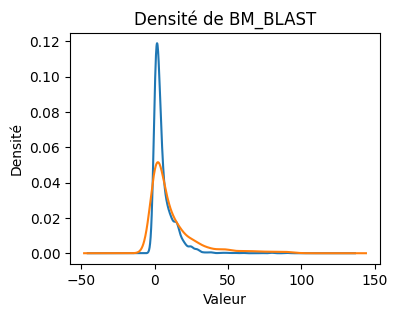

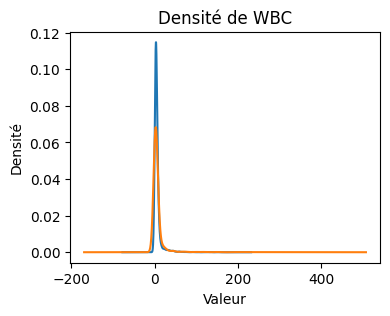

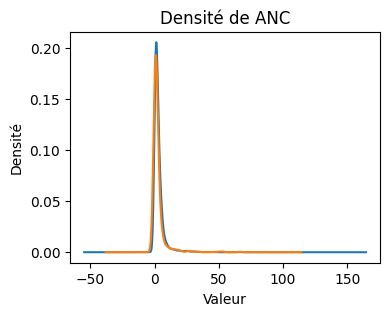

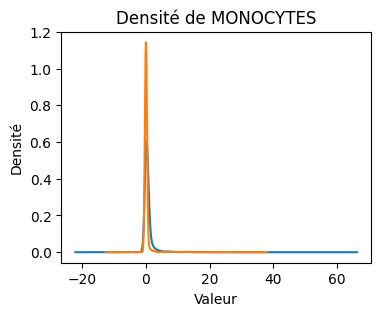

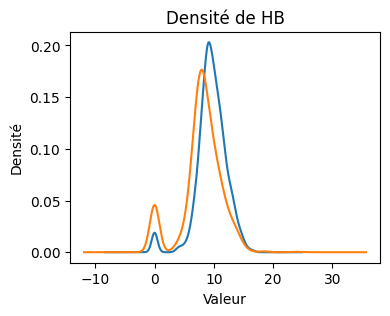

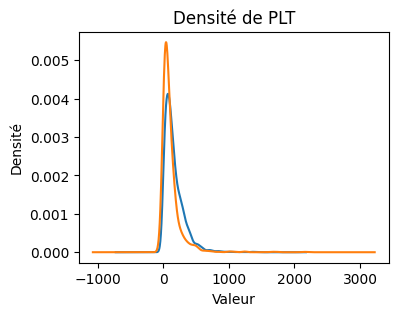

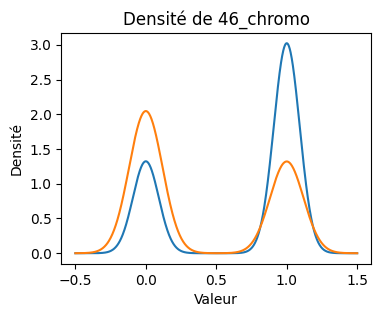

oupsis_normal


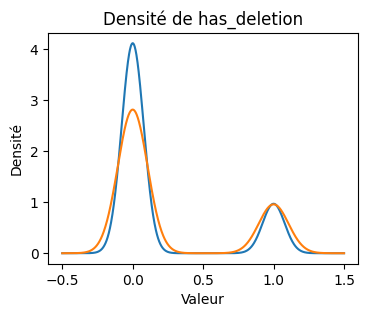

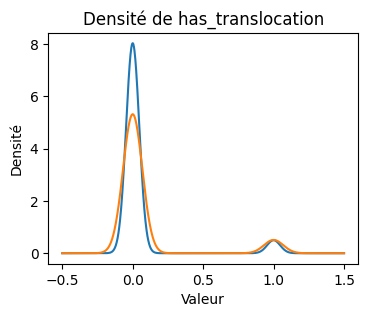

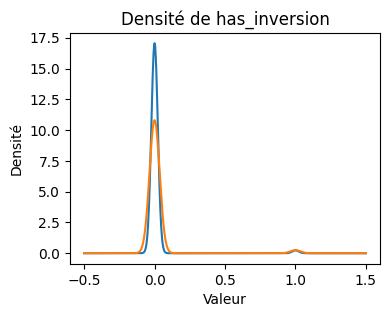

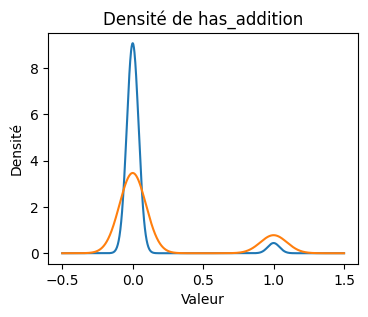

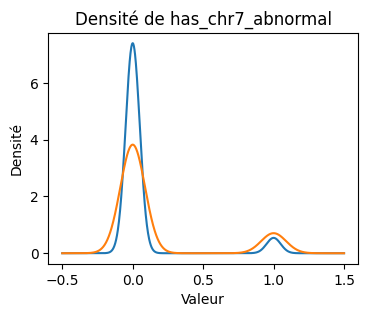

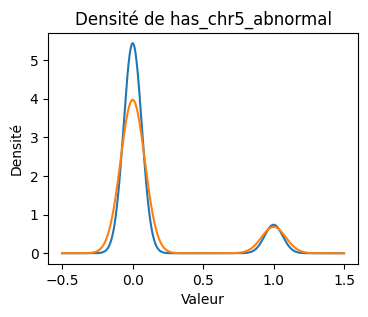

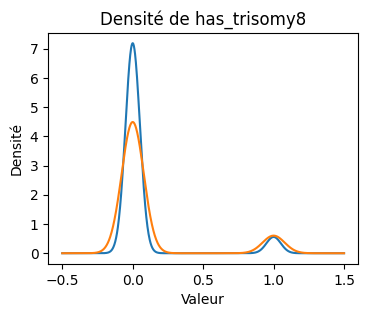

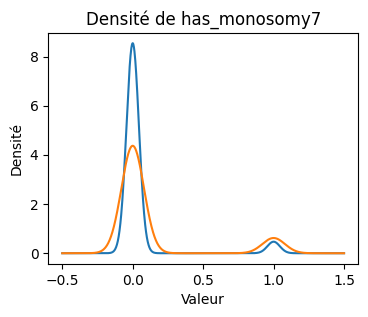

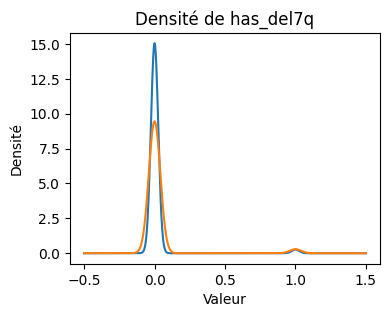

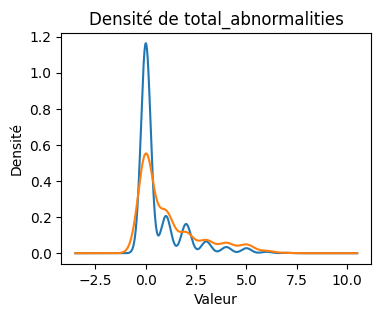

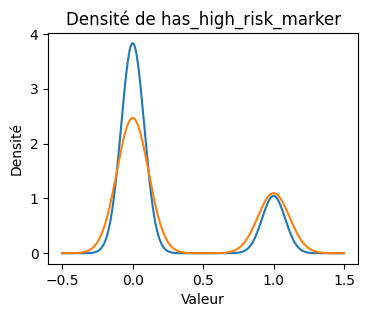

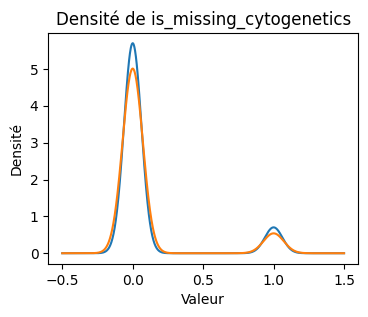

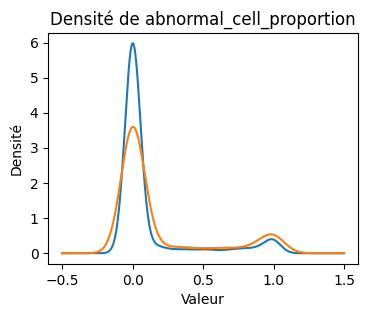

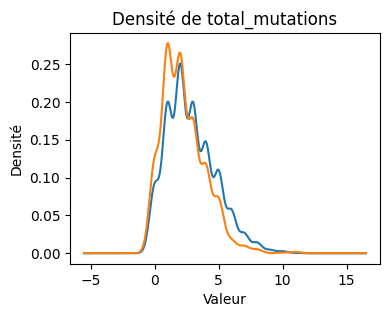

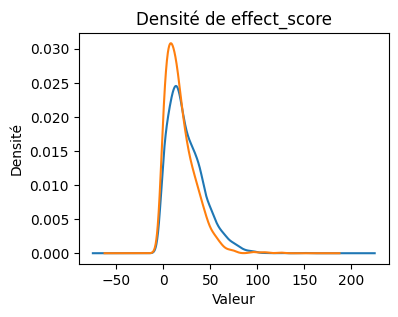

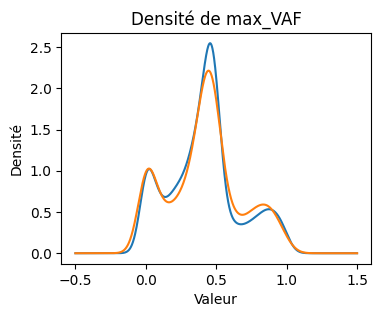

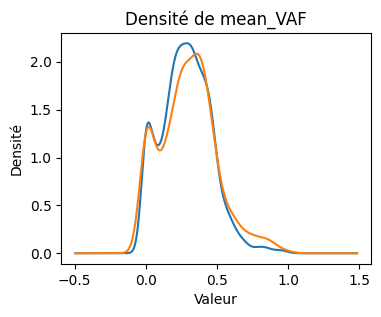

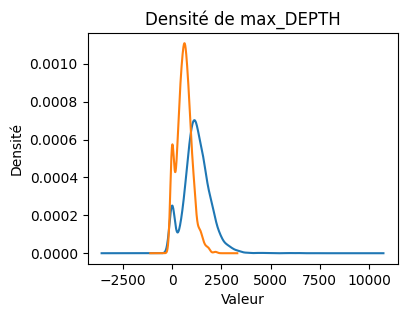

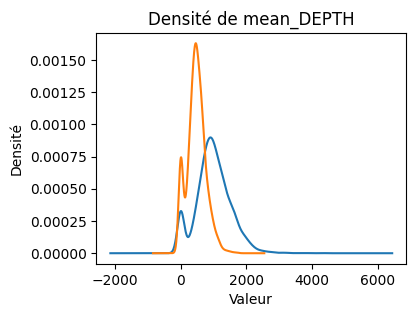

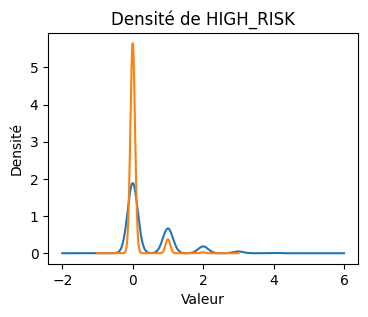

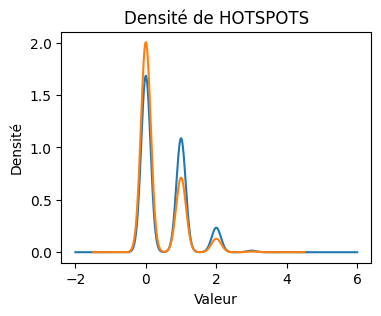

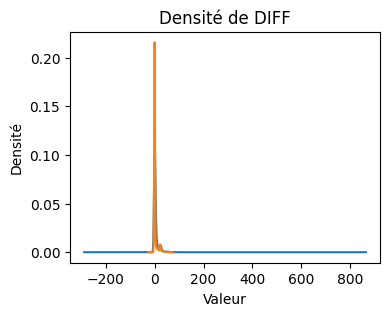

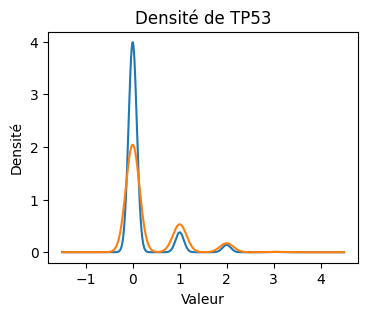

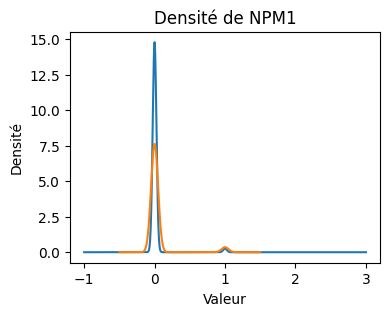

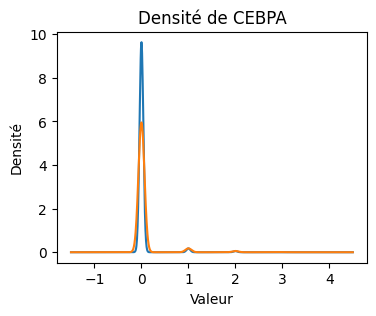

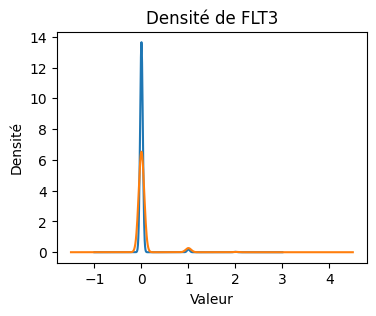

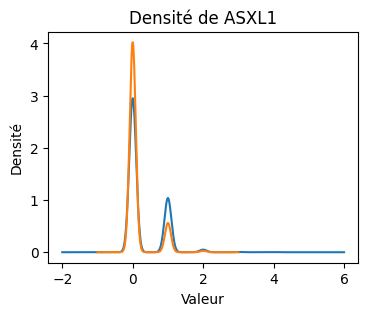

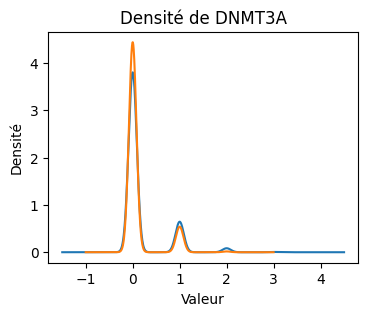

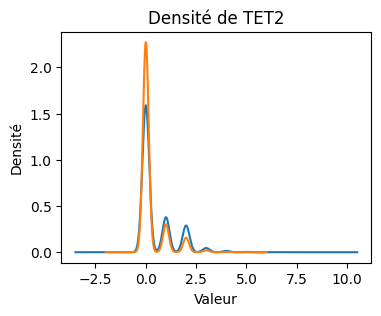

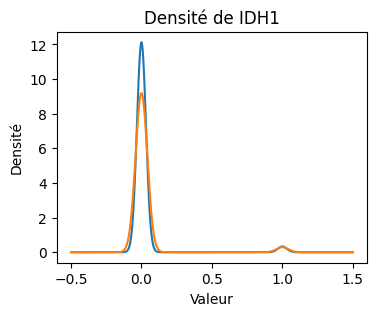

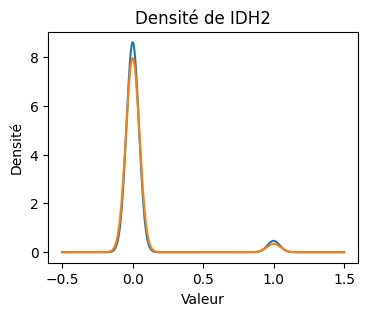

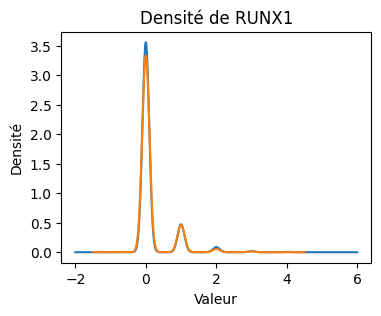

In [9]:
for colonne in list(df.columns) :
    try :
        df[colonne].plot(kind="kde" , figsize = (4,3) )
        df_eval[colonne].plot(kind="kde", figsize = (4,3))

        plt.xlabel("Valeur")
        plt.ylabel("Densité")
        plt.title(f"Densité de {colonne}")
        plt.show()

    except :
        print(f"oups{colonne}")


In [10]:
# Now split
X_train, X_test, y_train, y_test = train_test_split(df, target_df, test_size=0.3, random_state=42)

In [11]:
from sksurv.util import Surv
y_train_struct = Surv.from_dataframe('OS_STATUS', 'OS_YEARS', y_train)
y_test_struct = Surv.from_dataframe('OS_STATUS', 'OS_YEARS', y_test)

# Machine Learning

In [12]:
#Importing the necessary libraries

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sksurv.ensemble import RandomSurvivalForest
from sksurv.linear_model import CoxPHSurvivalAnalysis, CoxnetSurvivalAnalysis , IPCRidge
from sksurv.metrics import concordance_index_censored , concordance_index_ipcw
from sklearn.impute import SimpleImputer

### A simple model

In [ ]:
#We use coxnet survival analysis
coxnet = CoxnetSurvivalAnalysis(
    n_alphas=200, 
    alphas=None, 
    alpha_min_ratio='auto',
    l1_ratio=0.3,
    penalty_factor=None,
    normalize=False,
    copy_X=True,
    tol=1e-09,
    max_iter=100000,
    verbose=True,
    fit_baseline_model=False,
      )
#We fit the model
coxnet.fit(X_train, y_train_struct)      
#We predict the survival function
y_pred = coxnet.predict(X_test)

#We calculate the concordance index
c_index = concordance_index_censored(y_test_struct['OS_YEARS'], y_test_struct['OS_STATUS'], y_pred)
print(f"Coxnet Concordance Index: {c_index[0]}")
#we also calculate the IPCW concordance index
ipcw_c_index = concordance_index_ipcw(survival_test=y_test_struct, survival_train=y_train_struct, estimate= y_pred )
print(f"Coxnet IPCW Concordance Index: {ipcw_c_index[0]}")

### More complex models

#### Gradient Boost

In [ ]:
from sksurv.ensemble import GradientBoostingSurvivalAnalysis
from sksurv.ensemble import ComponentwiseGradientBoostingSurvivalAnalysis
from sklearn.model_selection import KFold
from sksurv.metrics import concordance_index_ipcw
from scipy.stats import uniform
from joblib import Parallel, delayed
import numpy as np
import os

# Nombre d'itérations de random search
n_iter = 25
n_splits = 10
n_jobs = n_splits # Nombre de folds traités en parallèle

best_score = float('-inf')
best_params = None

def eval_one_fold(train_index, val_index, params, X_train, y_train_struct):
    try:
        X_train_fold = X_train.iloc[train_index]
        X_val_fold = X_train.iloc[val_index]
        y_train_fold = y_train_struct[train_index]
        y_val_fold = y_train_struct[val_index]

        model = GradientBoostingSurvivalAnalysis(**params, random_state=0)
        model.fit(X_train_fold, y_train_fold)
        y_pred = model.predict(X_val_fold)

        score = concordance_index_ipcw(
            survival_train=y_train_fold,
            survival_test=y_val_fold,
            estimate=y_pred
        )[0]
        return score
    except Exception as e:
        print(f"Fold failed with exception: {e}")
        return None

for i in range(n_iter):
    # Hyperparamètres aléatoires
    params = {
        "learning_rate": uniform.rvs(loc=0.001, scale=0.1),
        "n_estimators": int(uniform.rvs(loc=400, scale=1200)),  
        "max_depth": int(uniform.rvs(loc=4, scale=14)),
        "min_samples_split": int(uniform.rvs(loc=10, scale=100)),
        "min_samples_leaf": int(uniform.rvs(loc=1, scale=10)),
        "subsample": uniform.rvs(loc=0.5, scale=0.45),
        "dropout_rate": uniform.rvs(loc=0.1, scale=0.5),
        "validation_fraction": 0.2
    }

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=i)
    folds = list(kf.split(X_train, y_train_struct))

    # Parallélisation ici
    fold_scores = Parallel(n_jobs=n_jobs)(
        delayed(eval_one_fold)(train_idx, val_idx, params, X_train, y_train_struct)
        for train_idx, val_idx in folds
    )

    # Supprime les folds échoués
    fold_scores = [s for s in fold_scores if s is not None]

    if fold_scores:
        mean_score = np.mean(fold_scores)
        if mean_score > best_score:
            best_score = mean_score
            best_params = params

    print(f"[{i+1}/{n_iter}] Score moyen : {np.round(np.mean(fold_scores), 4)}", flush=True)

# Affichage des meilleurs paramètres
print("\nMeilleurs paramètres :", best_params)
print("Score moyen sur validation croisée :", best_score)

# Ré-entraîner avec les meilleurs paramètres
best_model_CGB = GradientBoostingSurvivalAnalysis(**best_params, random_state=0)
best_model_CGB.fit(X_train, y_train_struct)

# Évaluation finale
y_pred_cgboost = best_model_CGB.predict(X_test)
ipcw_c_index_cgboost = concordance_index_ipcw(
    survival_train=y_train_struct,
    survival_test=y_test_struct,
    estimate=y_pred_cgboost
)

print(f"CGBoost IPCW Concordance Index sur test : {ipcw_c_index_cgboost[0]}")


The best model is : 




In [ ]:
# Align the columns of df_eval with X_train
df_eval = df_eval.reindex(columns=X_train.columns)
df_eval.fillna(0, inplace= True)

#We predict the survival function for the test set
y_pred_test = best_model_CGB.predict(df_eval)

In [ ]:
#We export the predictions to a csv file
df = pd.read_csv("X_test/clinical_test.csv")

predictions_df = pd.DataFrame({
    'ID': df['ID'],
    'risk_score': y_pred_test,
})
predictions_df.to_csv('submition_GBoost.csv', index=False)

#### Survival Forest

In [49]:
from sksurv.ensemble import RandomSurvivalForest
from sklearn.model_selection import KFold
from sksurv.metrics import concordance_index_ipcw
from scipy.stats import uniform, randint
from joblib import Parallel, delayed
import numpy as np

n_iter = 10
n_splits = 3
n_jobs = n_splits   # ajuster selon CPU

best_params = None
best_score = float('-inf')

def eval_one_fold(train_idx, val_idx, params, X_train, y_train_struct):
    try:
        X_train_fold = X_train.iloc[train_idx]
        X_val_fold = X_train.iloc[val_idx]
        y_train_fold = y_train_struct[train_idx]
        y_val_fold = y_train_struct[val_idx]

        model = RandomSurvivalForest(**params, random_state=0)
        model.fit(X_train_fold, y_train_fold)
        y_pred = model.predict(X_val_fold)

        score = concordance_index_ipcw(
            survival_train=y_train_fold,
            survival_test=y_val_fold,
            estimate=y_pred
        )[0]
        return score
    except Exception as e:
        print(f"Fold failed with exception: {e}")
        return None

for i in range(n_iter):
    params = {
        "n_estimators": int(uniform.rvs(loc=1000, scale=20000)),
        "max_depth": int(uniform.rvs(loc=8, scale=14)),
        "min_samples_split": int(uniform.rvs(loc=2, scale=5)),
        "min_samples_leaf": int(uniform.rvs(loc=1, scale=3)),
        "max_features": ['sqrt', 'log2'][np.random.choice(2)],
        "min_weight_fraction_leaf": 0.0,
        "n_jobs": -1,
        "max_leaf_nodes": int(uniform.rvs(loc=30, scale=200))
    }

kf = KFold(n_splits=n_splits, shuffle=True, random_state=i)
folds = list(kf.split(X_train, y_train_struct))

fold_scores = Parallel(n_jobs=n_jobs)(
    delayed(eval_one_fold)(train_idx, val_idx, params, X_train, y_train_struct)
    for train_idx, val_idx in folds
)
fold_scores = [s for s in fold_scores if s is not None]

if fold_scores:
    mean_score = np.mean(fold_scores)
    if mean_score > best_score:
        best_score = mean_score
        best_params = params

print(f"[{i+1}/{n_iter}] Score moyen : {np.round(np.mean(fold_scores), 4)}", flush=True)

print("\nMeilleurs paramètres :", best_params)
print("Score moyen sur validation croisée :", best_score)

best_model_rf = RandomSurvivalForest(**best_params, random_state=0)
best_model_rf.fit(X_train, y_train_struct)

y_pred_rf = best_model_rf.predict(X_test)
ipcw_c_index_rf = concordance_index_ipcw(
    survival_train=y_train_struct,
    survival_test=y_test_struct,
    estimate=y_pred_rf
)

print(f"Random Forest IPCW Concordance Index sur test : {ipcw_c_index_rf[0]}")

[10/10] Score moyen : nan


c:\Users\marec\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\marec\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)



Meilleurs paramètres : None
Score moyen sur validation croisée : -inf


TypeError: sksurv.ensemble.forest.RandomSurvivalForest() argument after ** must be a mapping, not NoneType

In [ ]:
# Align the columns of df_eval with X_train
df_eval = df_eval.reindex(columns=X_train.columns)

#We predict the survival function for the test set
y_pred_test = best_model_rf.predict(df_eval)

In [ ]:
#We export the predictions to a csv file

df = pd.read_csv("X_test\clinical_test.csv")

predictions_df = pd.DataFrame({
    'ID': df['ID'],
    'risk_score': y_pred_test,
})
predictions_df.to_csv('submission_rdm_forest.csv', index=False)

#### Xgboost

In [24]:
import numpy as np
import xgboost as xgb


dtrain = xgb.DMatrix(X_train)

# Associate ranged labels with the data matrix.
# This example shows each kind of censored labels.
#                         uncensored    right     left  interval

y_lower_bound = np.array(y_train["OS_YEARS"])
y_temp = y_train.copy()

y_temp["upper_bound"] = np.where(y_temp["OS_STATUS"], np.inf, y_temp["OS_YEARS"])

y_upper_bound = np.array(y_temp["upper_bound"])


dtrain.set_float_info('label_lower_bound', y_lower_bound)
dtrain.set_float_info('label_upper_bound', y_upper_bound)



dtest = xgb.DMatrix(X_test)


y_lower_bound = np.array(y_test["OS_YEARS"])
y_temp = y_test.copy()

y_temp["upper_bound"] = np.where(y_temp["OS_STATUS"], np.inf, y_temp["OS_YEARS"])

y_upper_bound = np.array(y_temp["upper_bound"])


dtest.set_float_info('label_lower_bound', y_lower_bound)
dtest.set_float_info('label_upper_bound', y_upper_bound)


In [43]:
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from sksurv.metrics import concordance_index_ipcw
import numpy as np

space = {
    'learning_rate': hp.loguniform('learning_rate', -9, -2),
    'max_depth': hp.choice('max_depth', range(3, 10)),
    'min_child_weight': hp.quniform('min_child_weight', 1, 6, 1),
    'subsample': hp.uniform('subsample', 0.6, 1),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 1),
    'gamma': hp.uniform('gamma', 0, 0.5),
    'alpha': hp.uniform('alpha', 0, 0.5),
    'lambda': hp.uniform('lambda', 0.5, 1.5),
    'max_leaves': hp.choice('max_leaves', [32, 64, 128, 256]),
    'aft_loss_distribution_scale': hp.uniform('aft_loss_distribution_scale', 1.0, 1.5)
}

def objective(space):
    params = {
        'objective': 'survival:aft',
        'aft_loss_distribution': 'normal',
        'tree_method': 'hist',
        'learning_rate': space['learning_rate'],
        'max_depth': int(space['max_depth']),
        'min_child_weight': space['min_child_weight'],
        'subsample': space['subsample'],
        'colsample_bytree': space['colsample_bytree'],
        'gamma': space['gamma'],
        'alpha': space['alpha'],
        'lambda': space['lambda'],
        'max_leaves': int(space['max_leaves']),
        'aft_loss_distribution_scale': space['aft_loss_distribution_scale']
    }

    # Train model
    bst = xgb.train(
        params,
        dtrain,
        num_boost_round=20000,
        early_stopping_rounds=75,
        evals=[(dtrain, 'train')],
        verbose_eval=False  # Reduce verbosity
    )
    
    y_pred = bst.predict(dtest)
    risk = concordance_index_ipcw(survival_train=y_train_struct, survival_test=y_test_struct, estimate= y_pred)[0]

    # Return the concordance index
    return {'loss': -risk, 'status': STATUS_OK}

trials = Trials()
best = fmin(fn=objective,
            space=space,
            algo=tpe.suggest,
            max_evals=100,  # Number of iterations
            trials=trials)

print("Best parameters found:\n", best)

# Use the best parameters to train the final model
best_params = {
    'objective': 'survival:aft',
    'aft_loss_distribution': 'normal',
    'tree_method': 'hist',
    'learning_rate': best['learning_rate'],
    'max_depth': int(best['max_depth']),
    'min_child_weight': best['min_child_weight'],
    'subsample': best['subsample'],
    'colsample_bytree': best['colsample_bytree'],
    'gamma': best['gamma'],
    'alpha': best['alpha'],
    'lambda': best['lambda'],
    'max_leaves': int(best['max_leaves']),
    'aft_loss_distribution_scale': best['aft_loss_distribution_scale']
}

# Train final model
final_model = xgb.train(
    best_params,
    dtrain,
    num_boost_round=20000,
    early_stopping_rounds=75,  # Use the best number of rounds
    evals=[(dtest, 'test')],
    verbose_eval=False
)

100%|██████████| 100/100 [05:13<00:00,  3.14s/trial, best loss: -0.562372198600485]
Best parameters found:
 {'aft_loss_distribution_scale': np.float64(1.4366458829174777), 'alpha': np.float64(0.3894700921733978), 'colsample_bytree': np.float64(0.9396722355232269), 'gamma': np.float64(0.20750426743864203), 'lambda': np.float64(0.6778961245177427), 'learning_rate': np.float64(0.05171840995367716), 'max_depth': np.int64(5), 'max_leaves': np.int64(0), 'min_child_weight': np.float64(4.0), 'subsample': np.float64(0.9450024532179409)}


In [ ]:
y_pred = final_model.predict(dtest)

risk = sksurv.metrics.concordance_index_ipcw(y_train_struct, y_test_struct, y_pred)[0]

np.float64(0.5)

In [28]:
df = pd.read_csv("X_test\clinical_test.csv")

predictions_df = pd.DataFrame({
    'ID': df['ID'],
    'risk_score': y_pred,
})
predictions_df.to_csv('submission_xgboost.csv', index=False)

<>:1: SyntaxWarning: invalid escape sequence '\c'
<>:1: SyntaxWarning: invalid escape sequence '\c'
C:\Users\marec\AppData\Local\Temp\ipykernel_28108\3630727344.py:1: SyntaxWarning: invalid escape sequence '\c'
  df = pd.read_csv("X_test\clinical_test.csv")
